# A stack with axes

- `protein_transport` is 4D: time, channel, y, x.
- An op that takes one plane has to be told what the other axes are.
- First look at the data.

In [1]:
import matplotlib.pyplot as plt
from skimage import data

stack = data.protein_transport()
AXES = ["t", "c", "y", "x"]

print(f"shape {stack.shape}  dtype {stack.dtype}")
for name, size in zip(AXES, stack.shape):
    print(f"  {name}: {size}")

shape (15, 2, 180, 183)  dtype uint8
  t: 15
  c: 2
  y: 180
  x: 183


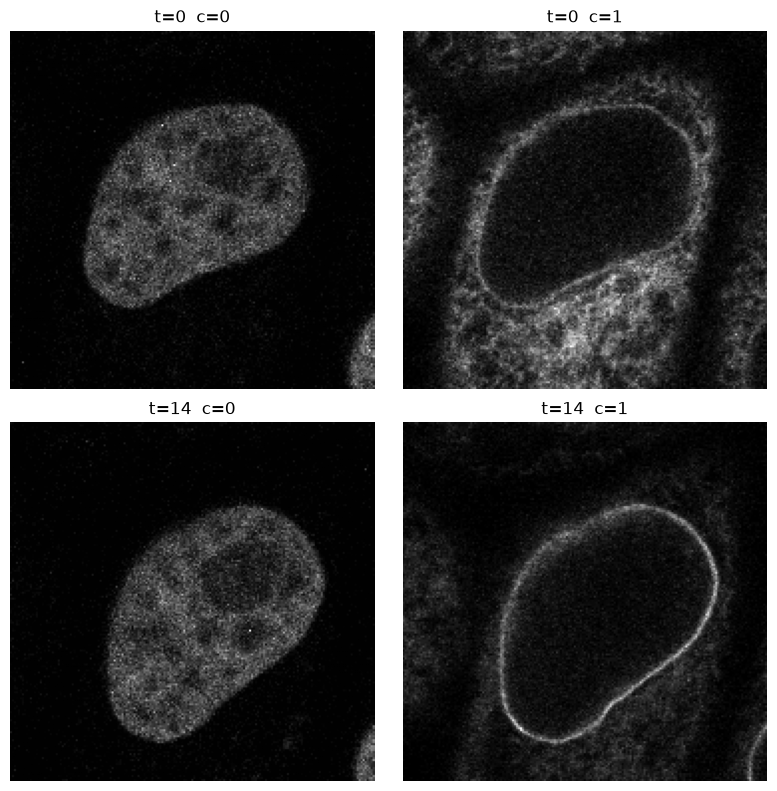

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, t in enumerate([0, 14]):
    for col, c in enumerate([0, 1]):
        ax = axes[row, col]
        ax.imshow(stack[t, c], cmap="gray")
        ax.set_title(f"t={t}  c={c}")
        ax.axis("off")
fig.tight_layout()

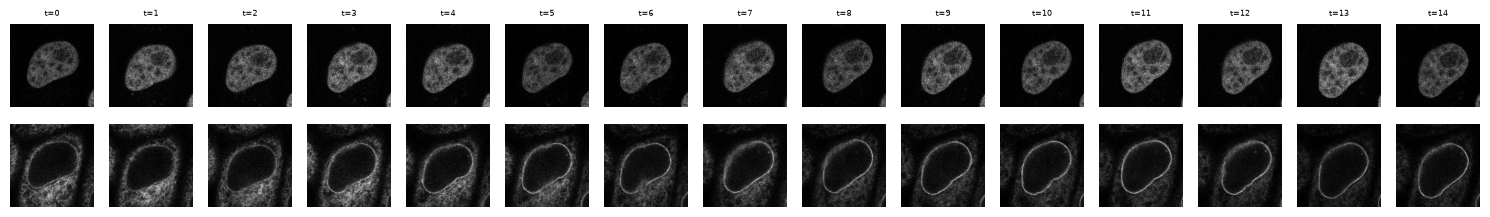

In [3]:
fig, axes = plt.subplots(2, 15, figsize=(15, 2.4))
for c in range(stack.shape[1]):
    for t in range(stack.shape[0]):
        ax = axes[c, t]
        ax.imshow(stack[t, c], cmap="gray")
        ax.axis("off")
        if c == 0:
            ax.set_title(f"t={t}", fontsize=6)
    axes[c, 0].set_ylabel(f"c={c}")
fig.tight_layout()

## Canny on the stack

Canny is 2D only.

In [4]:
from skimage import feature

try:
    feature.canny(stack)
except ValueError as e:
    print(e)

The parameter `image` must be a 2-dimensional array


## As an op

`Axes("y", "x")` says: one plane per call.

In [5]:
from typing import Annotated

import numpy as np

from opspec.op import Axes, op
from opspec.types import ImageOf
from opspec.plan import plan


@op
def edges(
    image: Annotated[ImageOf[np.ndarray], Axes("y", "x")],
    sigma: float = 2.0,
) -> ImageOf[np.ndarray]:
    return feature.canny(image, sigma=sigma)

## The plan

What the caller has, against what the op takes.

In [6]:
p = plan(edges, "image", stack, AXES)

print(p.summary)
print(f"iterate axes {p.iterate}, {p.calls} calls")
print(f"slots filled by input axes {p.mapping}")

run 30 times, once per t/c position
iterate axes (0, 1), 30 calls
slots filled by input axes (2, 3)


In [ ]:
for a in p.iterate:
    print(a)
    array

0
1


## Carry it out

Below we run the loops with not too concise code to make it easier to follow how the indexes are generateted from the plan. 

In [16]:
def run(the_op, p, array, **kwargs):
    indexes = p.iterate
    print(f"iterate axes indexes {indexes}")
    sizes = []
    for a in indexes:
        sizes.append(array.shape[a])

    print(f"iterate axes sizes {sizes}")

    results = []
    for i in range(sizes[0]):
        for j in range(sizes[1]):
            print(f"running {the_op.__name__} on array[{i}, {j}]")
            results.append(the_op(array[i, j], **kwargs))

    return np.asarray(results).reshape(*sizes, *results[0].shape)


edge_stack = run(edges, p, stack)
print(edge_stack.shape, edge_stack.dtype)

iterate axes indexes (0, 1)
iterate axes sizes [15, 2]
running edges on array[0, 0]
running edges on array[0, 1]
running edges on array[1, 0]
running edges on array[1, 1]
running edges on array[2, 0]
running edges on array[2, 1]
running edges on array[3, 0]
running edges on array[3, 1]
running edges on array[4, 0]
running edges on array[4, 1]
running edges on array[5, 0]
running edges on array[5, 1]
running edges on array[6, 0]
running edges on array[6, 1]
running edges on array[7, 0]
running edges on array[7, 1]
running edges on array[8, 0]
running edges on array[8, 1]
running edges on array[9, 0]
running edges on array[9, 1]
running edges on array[10, 0]
running edges on array[10, 1]
running edges on array[11, 0]
running edges on array[11, 1]
running edges on array[12, 0]
running edges on array[12, 1]
running edges on array[13, 0]
running edges on array[13, 1]
running edges on array[14, 0]
running edges on array[14, 1]
(15, 2, 180, 183) bool


## A more Python version

`np.ndindex` walks the same positions, for any number of iterate axes.

In [ ]:
def run_short(the_op, p, array, **kwargs):
    sizes = [array.shape[a] for a in p.iterate]
    results = [the_op(array[i], **kwargs) for i in np.ndindex(*sizes)]
    return np.asarray(results).reshape(*sizes, *results[0].shape)


edge_stack = run_short(edges, p, stack)
print(edge_stack.shape, edge_stack.dtype)

##  A more pythonic version

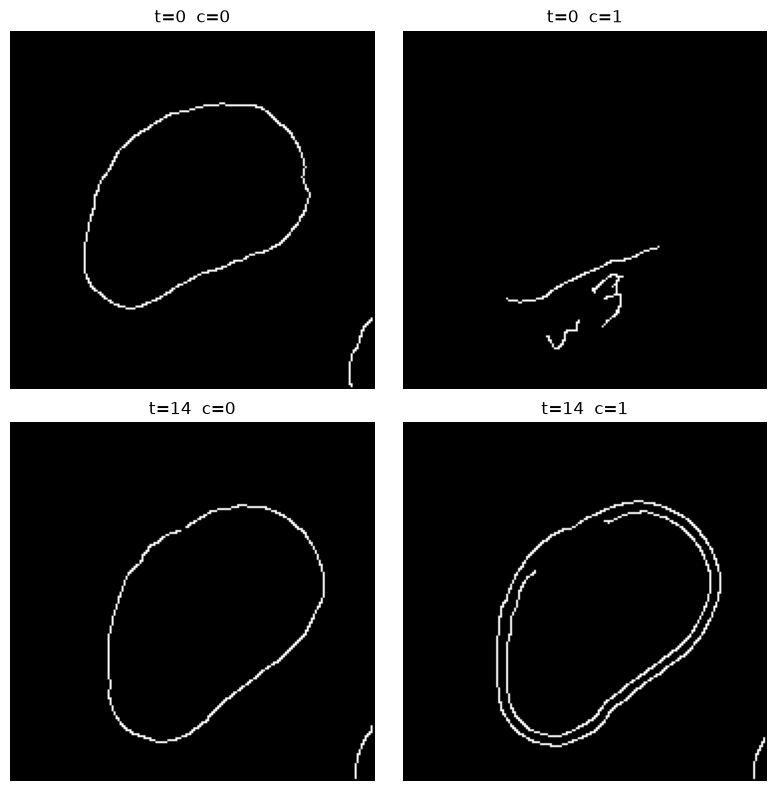

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, t in enumerate([0, 14]):
    for col, c in enumerate([0, 1]):
        ax = axes[row, col]
        ax.imshow(edge_stack[t, c], cmap="gray")
        ax.set_title(f"t={t}  c={c}")
        ax.axis("off")
fig.tight_layout()

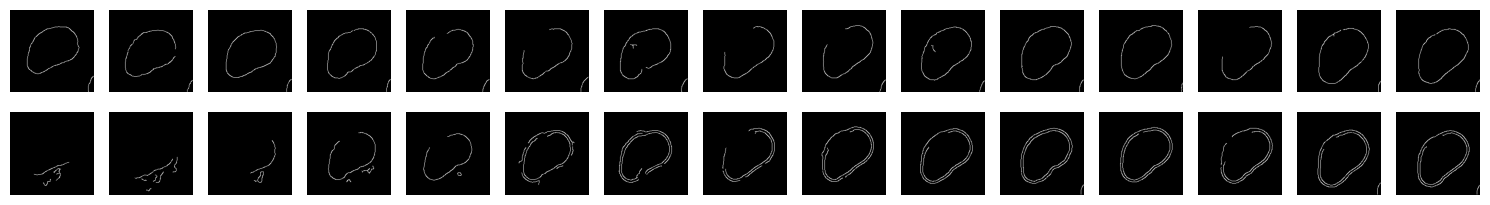

In [18]:
fig, axes = plt.subplots(2, 15, figsize=(15, 2.4))
for c in range(edge_stack.shape[1]):
    for t in range(edge_stack.shape[0]):
        axes[c, t].imshow(edge_stack[t, c], cmap="gray")
        axes[c, t].axis("off")
fig.tight_layout()